In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
# Load dataset

df = pd.read_csv("Advertising.csv.zip")

# Display first five rows

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
# Check missing values

df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [6]:
# Statistical summary

df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
print("Rows and Columns :", df.shape)

Rows and Columns : (200, 5)


In [8]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [9]:
# Correlation between columns

df.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


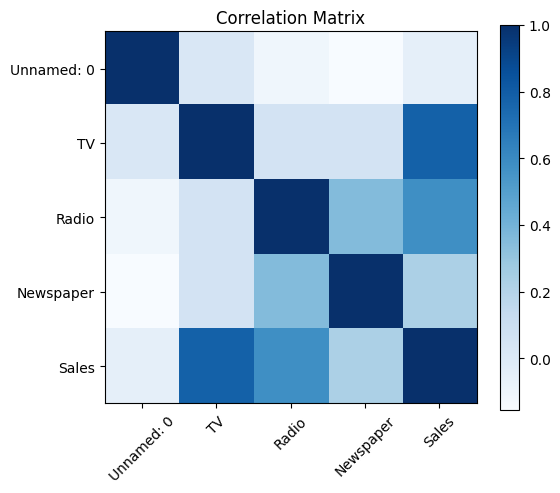

In [10]:
plt.figure(figsize=(6,5))

plt.imshow(df.corr(), cmap='Blues')

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=45)

plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")

plt.show()

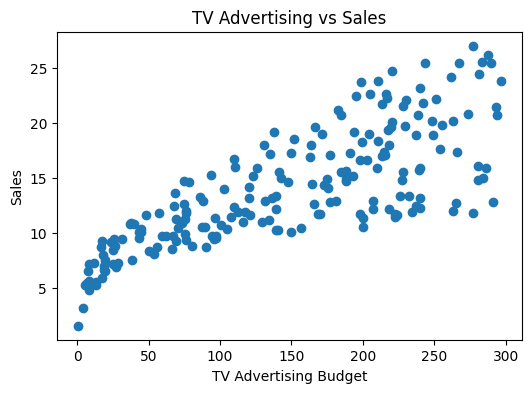

In [11]:
# TV Advertising vs Sales

plt.figure(figsize=(6,4))
plt.scatter(df['TV'], df['Sales'])
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.show()

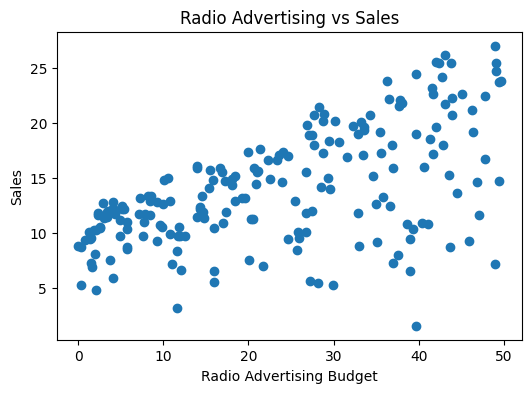

In [12]:
# Radio Advertising vs Sales

plt.figure(figsize=(6,4))
plt.scatter(df['Radio'], df['Sales'])
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.show()

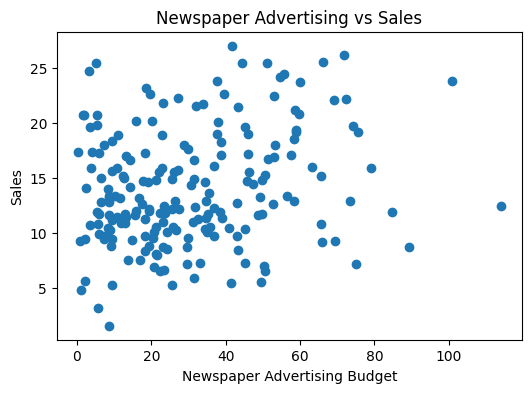

In [13]:
# Newspaper Advertising vs Sales

plt.figure(figsize=(6,4))
plt.scatter(df['Newspaper'], df['Sales'])
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.show()

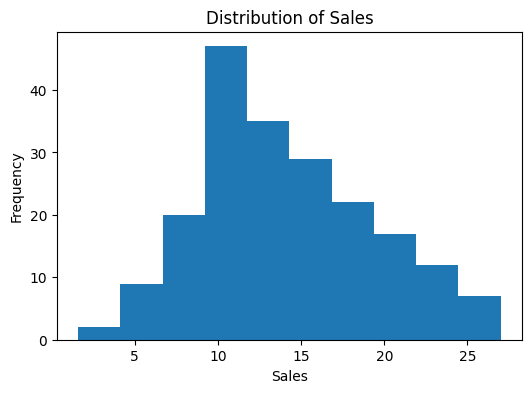

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['Sales'], bins=10)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [15]:
# Features

X = df[['TV', 'Radio', 'Newspaper']]

# Target

y = df['Sales']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 1.4607567168117603
Mean Squared Error : 3.1740973539761033
Root Mean Squared Error : 1.78159966153345
R2 Score : 0.899438024100912


In [21]:
new_data = pd.DataFrame({
    'TV': [230],
    'Radio': [37],
    'Newspaper': [69]
})

prediction = model.predict(new_data)

print("Predicted Sales :", prediction[0])

Predicted Sales : 20.45759025215365


In [22]:
new_data = pd.DataFrame({
    'TV': [341],
    'Radio': [47],
    'Newspaper': [79]
})

prediction = model.predict(new_data)

print("Predicted Sales :", prediction[0])

Predicted Sales : 27.342128376938597


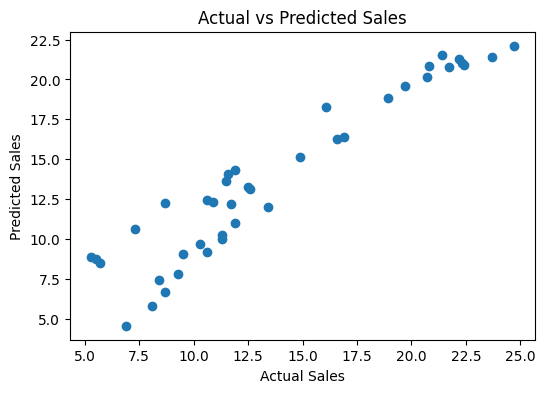

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()